In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [109]:
DATA_PATH = "../data/raw/PMAY-U_2025_dataset.csv"

df = pd.read_csv(DATA_PATH)

In [110]:
df.head()

,Country,State,Year,City,"Pradhan Mantri Awas Yojana (Pmay) Investment Amount (UOM:INR(IndianRupees)), Scaling Factor:10000000","Pradhan Mantri Awas Yojana (Pmay) Central Assistance Sanctioned (UOM:INR(IndianRupees)), Scaling Factor:10000000","Pradhan Mantri Awas Yojana (Pmay) Central Assistance Released (UOM:INR(IndianRupees)), Scaling Factor:10000000","Pradhan Mantri Awas Yojana (Pmay) Houses Sanctioned (UOM:Number), Scaling Factor:1","Pradhan Mantri Awas Yojana (Pmay) Houses Grounded (UOM:Number), Scaling Factor:1","Pradhan Mantri Awas Yojana (Pmay) Houses Completed (UOM:Number), Scaling Factor:1"
0,India,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2025","Port Blair, Municipality",95.8300,5.8400,2.9300,376.0000,376.0000,151.0000
1,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Addanki, Municipality",194.4100,66.5300,34.0200,4388.0000,3228.0000,2173.0000
2,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Adoni, Municipality",701.2400,220.5600,129.2000,14605.0000,11305.0000,9405.0000
3,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Akiveedu, Town Panchayat",42.8600,17.2200,9.7700,1136.0000,963.0000,579.0000
4,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Allagadda, Municipality",202.9500,53.7400,45.3200,3537.0000,3454.0000,3266.0000


In [111]:
df.shape

(5113, 10)

In [112]:
df = df.rename(columns={
    df.columns[0]: "Country",
    df.columns[1]: "State",
    df.columns[2]: "Year",
    df.columns[3]: "City",
    df.columns[4]: "Investment",
    df.columns[5]: "Central_assistance_sanctioned",
    df.columns[6]: "Central_assistance_released",
    df.columns[7]: "Houses_sanctioned",
    df.columns[8]: "Houses_grounded",
    df.columns[9]: "Houses_completed"
})

df.columns.tolist()

['Country',
 'State',
 'Year',
 'City',
 'Investment',
 'Central_assistance_sanctioned',
 'Central_assistance_released',
 'Houses_sanctioned',
 'Houses_grounded',
 'Houses_completed']

In [113]:
numerical_features = [
    "Investment",
    "Central_assistance_sanctioned",
    "Central_assistance_released",
    "Houses_sanctioned",
    "Houses_grounded",
    "Houses_completed"
]

X = df[numerical_features].copy()

In [114]:
print("Features used for anomaly detection:")
print(X.columns.tolist())

print("\nShape:", X.shape)

Features used for anomaly detection:
['Investment', 'Central_assistance_sanctioned', 'Central_assistance_released', 'Houses_sanctioned', 'Houses_grounded', 'Houses_completed']

Shape: (5113, 6)


In [115]:
X.dtypes

Investment                       float64
Central_assistance_sanctioned    float64
Central_assistance_released      float64
Houses_sanctioned                float64
Houses_grounded                  float64
Houses_completed                 float64
dtype: object

In [116]:
for column in numerical_features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

In [117]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Infinite values:", np.isinf(X).sum().sum())

Infinite values: 0


In [118]:
X.isnull().sum()

Investment                         0
Central_assistance_sanctioned      0
Central_assistance_released       46
Houses_sanctioned                  0
Houses_grounded                   88
Houses_completed                 229
dtype: int64

In [119]:
df[df["Houses_completed"].isna()][
    ["Houses_sanctioned", "Houses_grounded", "Houses_completed"]
].head(20)

,Houses_sanctioned,Houses_grounded,Houses_completed
62,92.0000,NaN,NaN
147,440.0000,NaN,NaN
153,10.0000,5.0000,NaN
155,31.0000,NaN,NaN
161,16.0000,4.0000,NaN
164,4.0000,NaN,NaN
165,258.0000,174.0000,NaN
166,72.0000,30.0000,NaN
167,16.0000,4.0000,NaN
171,81.0000,17.0000,NaN


In [120]:
df[df["Houses_completed"].isna()]["Houses_grounded"].describe()

count   141.0000
mean     84.1135
std     105.3182
min       1.0000
25%      17.0000
50%      53.0000
75%     106.0000
max     720.0000
Name: Houses_grounded, dtype: float64

In [121]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [122]:
negative_summary = (X < 0).sum()

negative_summary

Investment                       0
Central_assistance_sanctioned    0
Central_assistance_released      0
Houses_sanctioned                0
Houses_grounded                  0
Houses_completed                 0
dtype: int64

In [123]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Investment,5113.0000,161.0217,886.7353,0.0500,16.5900,41.6600,92.7900,26124.5900
Central_assistance_sanctioned,5113.0000,39.5813,149.5510,0.0100,5.3300,13.4800,29.7700,4349.1000
Central_assistance_released,5067.0000,34.0710,134.9661,0.0100,3.9400,10.8500,25.2300,4035.6800
Houses_sanctioned,5113.0000,2351.9167,8102.6825,1.0000,332.0000,849.0000,1888.0000,207593.0000
Houses_grounded,5025.0000,2168.2967,7901.4051,1.0000,264.0000,739.0000,1688.0000,205196.0000
Houses_completed,4884.0000,1855.3729,6829.3966,1.0000,245.0000,647.0000,1507.2500,194423.0000


In [124]:
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)
print("Training/reference set:", X_train.shape)
print("Test/holdout set:", X_test.shape)

Training/reference set: (4090, 6)
Test/holdout set: (1023, 6)


In [125]:
preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "power-transform",
        PowerTransformer(
            method="yeo-johnson",
            standardize=False
        )
    ),
    (
        "scaler",
        RobustScaler()
    )
])

print(preprocessor)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('power-transform', PowerTransformer(standardize=False)),
                ('scaler', RobustScaler())])


In [126]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (4090, 6)
Processed test shape: (1023, 6)


In [127]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=numerical_features,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=numerical_features,
    index=X_test.index
)

X_train_processed.head()

,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed
4881,0.0065,-0.2482,-0.1559,-0.4052,-0.3420,-0.3015
2905,-0.8895,-0.9534,-1.1184,-0.8833,-1.1847,-1.5373
3289,2.1343,1.9183,1.8392,2.4012,2.4350,2.6392
3914,0.5893,0.3203,-0.6993,0.3568,0.1876,0.2585
4879,-1.3387,-1.2098,-1.1150,-1.1664,-1.0732,-1.1060


In [128]:
print("Missing values after preprocessing:")
print(X_train_processed.isnull().sum())

print("\nInfinite values after preprocessing:")
print(np.isinf(X_train_processed).sum())

Missing values after preprocessing:
Investment                       0
Central_assistance_sanctioned    0
Central_assistance_released      0
Houses_sanctioned                0
Houses_grounded                  0
Houses_completed                 0
dtype: int64

Infinite values after preprocessing:
Investment                       0
Central_assistance_sanctioned    0
Central_assistance_released      0
Houses_sanctioned                0
Houses_grounded                  0
Houses_completed                 0
dtype: int64


In [129]:
comparison = pd.DataFrame({
    "Before_Mean": X_train.mean(),
    "Before_Median": X_train.median(),
    "Before_Std": X_train.std(),
    "After_Mean": X_train_processed.mean(),
    "After_Median": X_train_processed.median(),
    "After_Std": X_train_processed.std()
})

comparison

,Before_Mean,Before_Median,Before_Std,After_Mean,After_Median,After_Std
Investment,163.0385,41.5300,913.2024,-0.0384,0.0000,0.8326
Central_assistance_sanctioned,39.0225,13.4000,146.7099,-0.0345,0.0000,0.7643
Central_assistance_released,33.6541,10.8800,131.6755,-0.0449,0.0000,0.7339
Houses_sanctioned,2304.3645,848.0000,7858.4122,-0.0192,0.0000,0.8481
Houses_grounded,2121.7500,740.0000,7624.2226,-0.0394,0.0000,0.8586
Houses_completed,1822.7097,648.0000,6510.9550,-0.0250,0.0000,0.8669


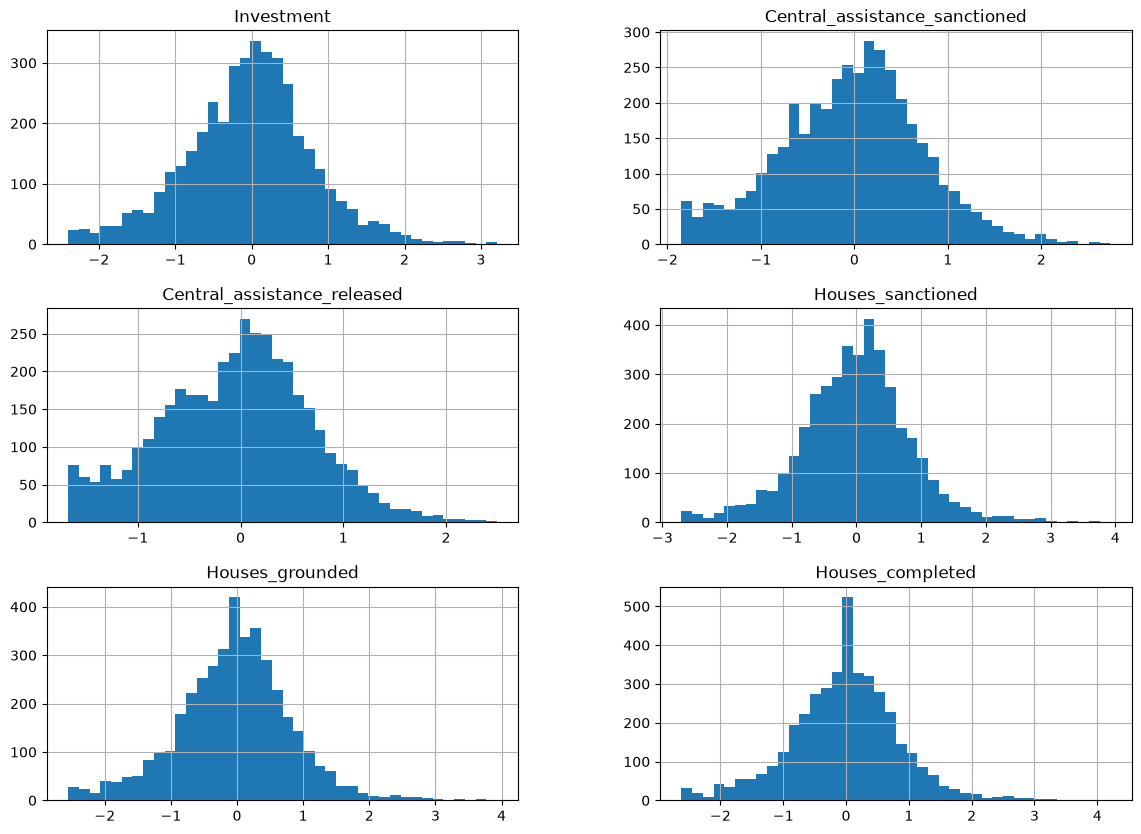

In [130]:
X_train_processed.hist(
    figsize=(14, 10),
    bins=40
)

plt.show()

In [131]:
processed_correlation = X_train_processed.corr()

processed_correlation

,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed
Investment,1.0000,0.9754,0.9188,0.9652,0.8873,0.8768
Central_assistance_sanctioned,0.9754,1.0000,0.9542,0.9910,0.9279,0.9115
Central_assistance_released,0.9188,0.9542,1.0000,0.9399,0.9462,0.9307
Houses_sanctioned,0.9652,0.9910,0.9399,1.0000,0.9319,0.9152
Houses_grounded,0.8873,0.9279,0.9462,0.9319,1.0000,0.9435
Houses_completed,0.8768,0.9115,0.9307,0.9152,0.9435,1.0000


In [132]:
X_train_processed.to_csv(
    "../data/processed/X_train_processed.csv",
    index=False
)

X_test_processed.to_csv(
    "../data/processed/X_test_processed.csv",
    index=False
)

print("Processed datasets saved.")

Processed datasets saved.


In [133]:
joblib.dump(
    preprocessor,
    "../src/models/preprocessor.joblib"
)


['../src/models/preprocessor.joblib']

In [134]:
X_processed = pd.DataFrame(
    preprocessor.transform(X),
    columns=numerical_features,
    index=X.index
)

X_processed.head()


,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed
0,0.4737,-0.4739,-0.6942,-0.4446,-0.3596,-0.7832
1,0.8623,0.8867,0.5979,0.9946,0.8573,0.7301
2,1.5347,1.4882,1.2307,1.8113,1.6753,1.7213
3,0.0181,0.1432,-0.0580,0.1673,0.1456,-0.0642
4,0.8855,0.7734,0.7408,0.8564,0.8993,0.9935


In [135]:
print("========== FINAL PREPROCESSING CHECK ==========")

print("Original dataset:", df.shape)
print("Modeling features:", len(numerical_features))

print("\nProcessed dataset:", X_processed.shape)

print("\nMissing values:")
print(X_processed.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_processed).sum().sum())

print("\nDuplicate processed rows:")
print(X_processed.duplicated().sum())

========== FINAL PREPROCESSING CHECK ==========
Original dataset: (5113, 10)
Modeling features: 6

Processed dataset: (5113, 6)

Missing values:
0

Infinite values:
0

Duplicate processed rows:
2


In [136]:
X_processed.to_csv(
    "../data/processed/X_processed.csv",
    index=False
)
